## Model Selection

In [40]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns

In [41]:
df = pd.read_csv("../../data/processed/features.csv")

df.shape

(50000, 28)

In [42]:
x = df.drop(["blew_up"], axis=1)
y = df["blew_up"]

categorical_columns = ["instrument", "market_regime"]
numeric_columns = [c for c in x.columns if c not in categorical_columns]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

print("Majority-class baseline accuracy:", round(baseline.score(X_test, y_test), 4))

Majority-class baseline accuracy: 0.5493


In [45]:
mi = mutual_info_classif(X_train[numeric_columns], y_train, random_state=42)

pd.Series(mi, index=numeric_columns).sort_values(ascending=False)

behavioral_risk               0.017670
position_sizing_discipline    0.016919
discipline_score              0.016214
uses_stop_loss                0.011204
chases_volatility             0.010466
follows_plan                  0.010321
revenge_trading               0.008738
overconfidence                0.007601
avg_leverage                  0.007546
trades_per_month              0.006128
leverage_risk                 0.005199
risk_per_trade_pct            0.004379
broker_cost_bps               0.003829
risk_amount                   0.003543
diversification               0.003329
trading_intensity             0.003022
age                           0.002920
journals_trades               0.001646
account_age_months            0.001181
experience_ratio              0.001161
prior_experience_years        0.000000
avg_loss_hold_days            0.000000
avg_win_hold_days             0.000000
loss_win_hold_ratio           0.000000
starting_capital              0.000000
dtype: float64

In [46]:
preprocess = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

In [47]:
models = {
    "HistGradientBoosting": (
        HistGradientBoostingClassifier(random_state=42),
        {
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_iter": [100, 200, 300],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [20, 30, 50],
            "model__l2_regularization": [0, 1, 10]
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            "model__n_neighbors": [5, 10, 15, 25],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    ),

    "Logistic Regression": (
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["lbfgs", "liblinear"]
        }
    ),

    "Gaussian NB": (
        GaussianNB(),
        {
            "model__var_smoothing": [1e-11, 1e-9, 1e-7, 1e-5]
        }
    ),

    "SVM": (
        SVC(
            kernel="rbf",
            class_weight="balanced"
        ),
        {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", 0.01, 0.1]
        }
    )
}

In [48]:
def positive_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    return estimator.decision_function(X)

In [49]:
results = []
best_models = {}
confusion_matrices = {}

for name, (model, parameters) in models.items():

    print(f"{name} running...")

    pipeline = Pipeline([
        ("pre", preprocess),
        ("model", model)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameters,
        cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        "model": name,
        "cv_balanced_acc": grid_search.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "test_auc": roc_auc_score(y_test, positive_scores(best_model, X_test)),
        "best_parameters": grid_search.best_params_
    })

    best_models[name] = best_model
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

HistGradientBoosting running...
KNN running...
Logistic Regression running...
Gaussian NB running...
SVM running...


In [50]:
results_df = pd.DataFrame(results)

results_df.sort_values("test_balanced_acc", ascending=False)

,model,cv_balanced_acc,test_accuracy,test_balanced_acc,test_auc,best_parameters
2,Logistic Regression,0.648871,0.6477,0.646800,0.701088,"{'model__C': 10, 'model__solver': 'lbfgs'}"
4,SVM,0.647671,0.6474,0.645253,0.700806,"{'model__C': 10, 'model__gamma': 0.01}"
0,HistGradientBoosting,0.641188,0.6466,0.636360,0.698059,"{'model__l2_regularization': 10, 'model__learn..."
3,Gaussian NB,0.625784,0.6367,0.627109,0.673013,{'model__var_smoothing': 1e-11}
1,KNN,0.593669,0.6131,0.598578,0.648563,"{'model__n_neighbors': 25, 'model__p': 1, 'mod..."


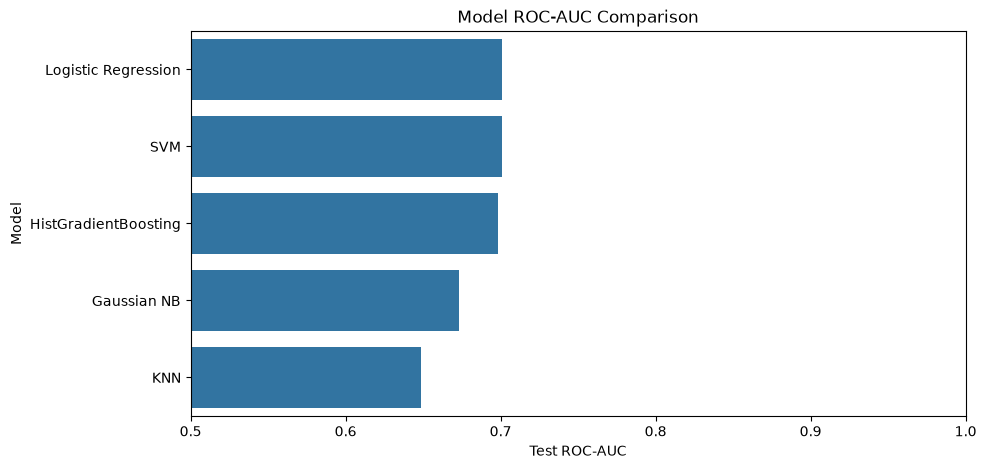

In [51]:
results_plot = results_df.sort_values("test_auc", ascending=False)

plot.figure(figsize=(10, 5))

sns.barplot(
    data=results_plot,
    x="test_auc",
    y="model"
)

plot.xlim(0.5, 1.0)
plot.xlabel("Test ROC-AUC")
plot.ylabel("Model")
plot.title("Model ROC-AUC Comparison")
plot.show()

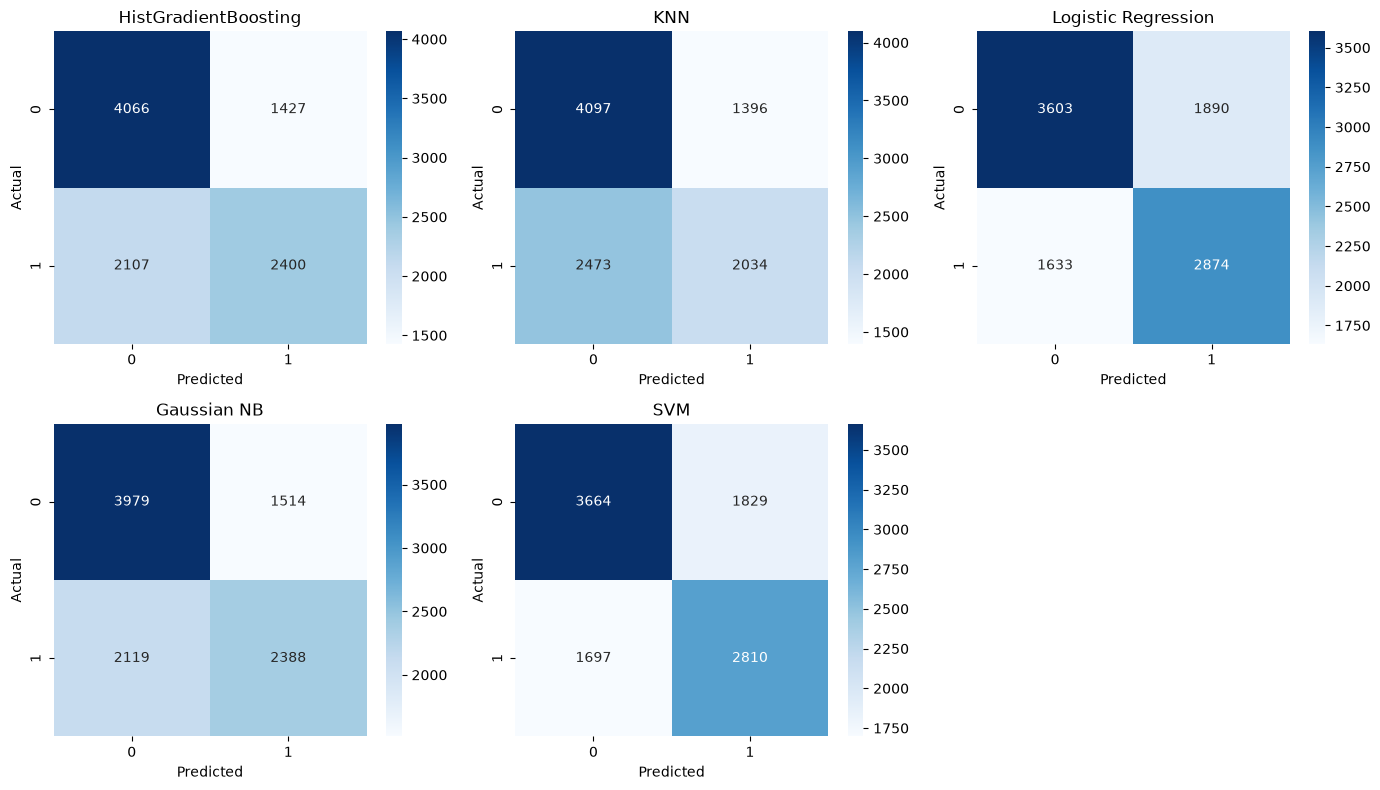

In [52]:
fig, axes = plot.subplots(
    2,
    3,
    figsize=(14, 8)
)

axes = axes.flatten()

for index, (name, matrix) in enumerate(confusion_matrices.items()):

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[index]
    )

    axes[index].set_title(name)
    axes[index].set_xlabel("Predicted")
    axes[index].set_ylabel("Actual")

for index in range(len(confusion_matrices), len(axes)):
    axes[index].axis("off")

plot.tight_layout()
plot.show()

In [53]:
best_model_name = results_df.loc[
    results_df["test_balanced_acc"].idxmax(),
    "model"
]

best_model = best_models[best_model_name]

print("The best model:", best_model_name)

The best model: Logistic Regression


In [54]:
print(
    classification_report(
        y_test,
        best_model.predict(X_test),
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.688     0.656     0.672      5493
           1      0.603     0.638     0.620      4507

    accuracy                          0.648     10000
   macro avg      0.646     0.647     0.646     10000
weighted avg      0.650     0.648     0.648     10000



In [55]:
if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(X_test)[:, 1]

    for t in [0.50, 0.45, 0.40, 0.35]:
        pred_t = (proba >= t).astype(int)
        r = recall_score(y_test, pred_t)
        p = precision_score(y_test, pred_t)
        print(f"threshold {t:.2f} -> recall {r:.3f} | precision {p:.3f}")
else:
    print("This model don't give predict proba. If it is SVC try SVC(probability=True).")

threshold 0.50 -> recall 0.638 | precision 0.603
threshold 0.45 -> recall 0.732 | precision 0.573
threshold 0.40 -> recall 0.811 | precision 0.545
threshold 0.35 -> recall 0.880 | precision 0.518


In [56]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

oof = cross_val_predict(best_model, X_train, y_train, cv=5, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)

target_recall = 0.80
mask = rec[:-1] >= target_recall
chosen = float(thr[mask].max()) if mask.any() else 0.0
print("seçilen eşik:", round(chosen, 3))

pred = (best_model.predict_proba(X_test)[:, 1] >= chosen).astype(int)
print(classification_report(y_test, pred, digits=3))
print(confusion_matrix(y_test, pred))

seçilen eşik: 0.406
              precision    recall  f1-score   support

           0      0.737     0.457     0.565      5493
           1      0.548     0.801     0.651      4507

    accuracy                          0.613     10000
   macro avg      0.643     0.629     0.608     10000
weighted avg      0.652     0.613     0.604     10000

[[2513 2980]
 [ 895 3612]]


## Conclusion

What was done. Five model families (HistGradientBoosting, KNN, Logistic Regression, Gaussian NB, SVM) were tuned with GridSearchCV on balanced_accuracy inside a leakage-free pipeline; scaling and encoding were fit only on the training portion of each CV fold.

Key finding — the ceiling is in the data, not the model. All five models clustered in the same band: test ROC-AUC ~0.70, accuracy ~0.65. A plain Logistic Regression (AUC 0.701) matched — and even edged out — a tuned HistGradientBoosting (AUC 0.698). When a linear model equals a complex ensemble, there is no additional structure left in the data for a stronger model to exploit; adding model complexity does not improve the result. Since the majority-class baseline is ~55%, an accuracy of ~65% corresponds to roughly 10 points of real but limited signal above baseline.

Selected model. Logistic Regression — it has the highest balanced_accuracy and AUC, and is also the simplest, fastest, and most interpretable model. Configuration: C=10, solver="lbfgs", class_weight="balanced", max_iter=2000.

Objective: catching blow-ups. The decision threshold was lowered from 0.50 to 0.406, raising class 1 (blew_up) recall to 0.80. The cost: precision drops to ~0.55 — 80% of traders who blow up are caught, but ~45% of those flagged as "at risk" do not actually blow up (false positives). This is the natural price of 0.80 recall on data with 0.70 AUC; it is a limit of the data, not a model flaw. The threshold was selected on out-of-fold training predictions to avoid overfitting to the test set.

In [64]:
from pathlib import Path
import joblib

artifact_dir = Path("../../artifacts")
artifact_dir.parent.mkdir(parents=True, exist_ok=True)

artifact_path = artifact_dir / "blowup_risk_logistic_v1_model.joblib"


lr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(C=10, solver="lbfgs", class_weight="balanced", max_iter=2000))
    ]
)

lr_pipeline.fit(x, y)

joblib.dump(lr_pipeline, artifact_path)

['../../artifacts/blowup_risk_logistic_v1_model.joblib']

In [65]:
loaded_model = joblib.load(artifact_path)

sample = x.iloc[[0]]

probability = loaded_model.predict_proba(sample)[0, 1]
prediction = loaded_model.predict(sample)[0]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 0
Probability: 0.4036386770808918


In [66]:
import json
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

artifact_dir = Path("../../artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Seçilen eşik
threshold = 0.406

# Test tahminleri
test_probability = lr_pipeline.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= threshold).astype(int)

metrics = {
    "model_name": "LogisticRegression",
    "model_version": "1.0.0",
    "threshold": threshold,
    "roc_auc": float(roc_auc_score(y_test, test_probability)),
    "precision": float(precision_score(y_test, test_prediction)),
    "recall": float(recall_score(y_test, test_prediction)),
    "f1": float(f1_score(y_test, test_prediction)),
    "feature_count": len(x.columns),
    "training_rows": len(x)
}

with open(artifact_dir / "metrics_v1.json", "w") as file:
    json.dump(metrics, file, indent=2)

with open(artifact_dir / "feature_schema_v1.json", "w") as file:
    json.dump({
        "features": list(x.columns),
        "feature_count": len(x.columns)
    }, file, indent=2)

print(metrics)

{'model_name': 'LogisticRegression', 'model_version': '1.0.0', 'threshold': 0.406, 'roc_auc': 0.7022496833313603, 'precision': 0.5490732300212702, 'recall': 0.8018637674728201, 'f1': 0.6518171160609613, 'feature_count': 27, 'training_rows': 50000}


In [67]:
print("Model input features:")
print(lr_pipeline.feature_names_in_.tolist())

Model input features:
['age', 'prior_experience_years', 'starting_capital', 'account_age_months', 'instrument', 'market_regime', 'broker_cost_bps', 'risk_per_trade_pct', 'avg_leverage', 'trades_per_month', 'uses_stop_loss', 'avg_win_hold_days', 'avg_loss_hold_days', 'diversification', 'journals_trades', 'revenge_trading', 'overconfidence', 'follows_plan', 'chases_volatility', 'position_sizing_discipline', 'risk_amount', 'leverage_risk', 'experience_ratio', 'trading_intensity', 'loss_win_hold_ratio', 'behavioral_risk', 'discipline_score']
